In [26]:
# EDA
import pandas as pd
import numpy as np

#Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

#-----Assess the structure-----

#Preview
df.head()
#check structure
df.shape
#metadata and types
df.info()
#Desciptive stats
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Data Cleaning

In [27]:
# duplicate rows
print(df.duplicated().sum())

0


No duplicated rows.

In [28]:
# Missing values

print(df.isnull().sum()) # count of mussing values per columnn

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


No Missing Rows

In [29]:
# Change totalcharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

# EDA

In [30]:
import matplotlib.pyplot as plt

<Axes: >

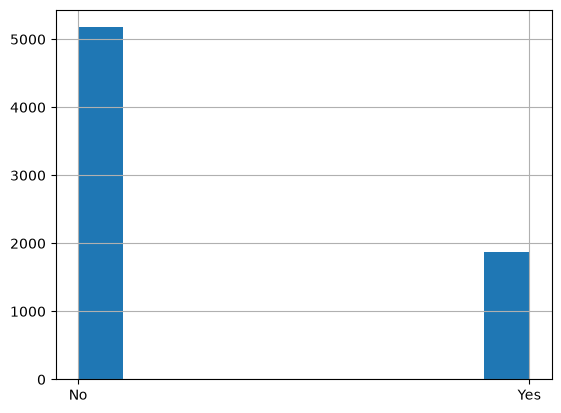

In [31]:
df['Churn'].hist()

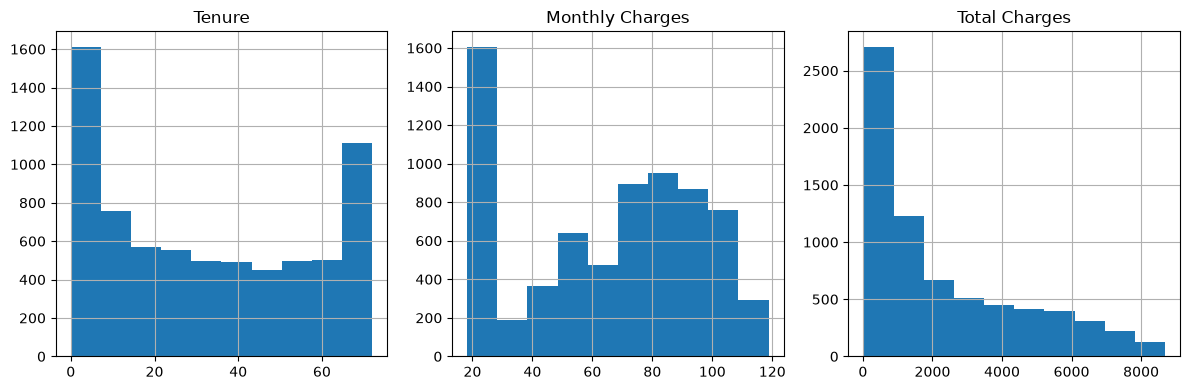

In [32]:


fig, axes = plt.subplots(1, 3, figsize=(12, 4))

df['tenure'].hist(ax=axes[0])
axes[0].set_title('Tenure')

df['MonthlyCharges'].hist(ax=axes[1])
axes[1].set_title('Monthly Charges')

df['TotalCharges'].hist(ax=axes[2])
axes[2].set_title('Total Charges')

plt.tight_layout()
plt.show()

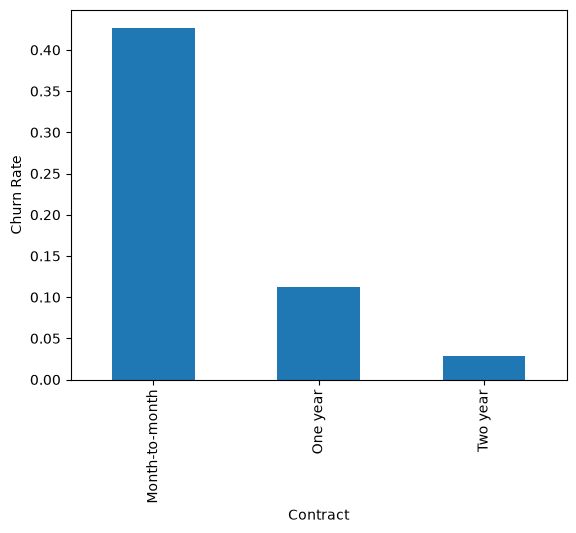

In [ ]:
# split the data into each contract type and taking mean of 1 and 0 values to see churn rates
df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean()).plot(kind='bar')
plt.ylabel('Churn Rate')
plt.show()

In [ ]:
# Making churn our binary variable
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

#Dropping customer id
df = df.drop(columns=['customerID'])

# Binary Yes no columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

In [ ]:
# multi class categoricals
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod',
                                  'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport', 'StreamingTV',
                                  'StreamingMovies'], drop_first=True, dtype= int)

In [ ]:
# Encode Gender 
df['gender'] = (df['gender'] == 'Male').astype(int)